In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

# ----------------------------------------

from audio.capture import audio_capture
from config import FRAME_MS, SAMPLE_RATE
from scipy.io.wavfile import write

DURATION = 5

# ----------------------------------------

from embeddings.encoder import SpeakerEncoder
from sklearn.decomposition import PCA


/Users/raiana/Codes/voice_detection/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/raiana/Codes/voice_detection/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [13]:
stream = audio_capture()
frames = []
num_frames = int(DURATION * 1000 / FRAME_MS)

for i, frame in enumerate(stream):
    frames.append(frame)

    if i >= num_frames - 1:
        break

audio = np.concatenate(frames)
write("../data/speaker2/audio_4.wav", SAMPLE_RATE, audio.astype(np.int16))

In [4]:
speaker_audio = {}

for speaker in [1, 2]:
    for recording in [1, 2, 3, 4]:
        filename = f"audio_{recording}.wav"
        sr, audio = wavfile.read(ROOT / "data" / f"speaker{speaker}" / filename)
        audio = audio.astype(np.float32) / 32768.0
        speaker_audio[(speaker, recording)] = (sr, audio)

In [ ]:
encoder = SpeakerEncoder()

embeddings = []
labels = []

for (speaker, recording), (sr, audio) in speaker_audio.items():
    embedding = encoder.encode(audio, sr)
    embeddings.append(embedding)
    labels.append(speaker)

X = np.array(embeddings)

# compressing 192 dimension embedding into 2 (dimensions where voice datasets vary most)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

/Users/raiana/Codes/voice_detection/.venv/lib/python3.9/site-packages/speechbrain/utils/checkpoints.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(path, ma

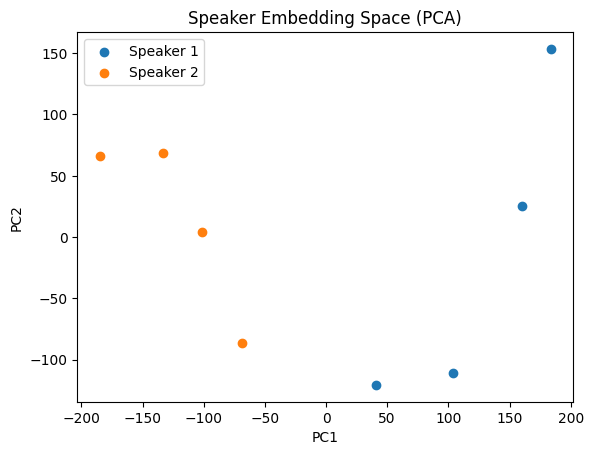

In [10]:
for speaker in set(labels):
    indices = [i for i, s in enumerate(labels) if s == speaker]

    plt.scatter(
        X_2d[indices, 0],
        X_2d[indices, 1],
        label=f"Speaker {speaker}"
    )

plt.legend()
plt.title("Speaker Embedding Space (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()